In [1]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,MessagesState
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.utilities import GoogleSerperAPIWrapper,WikipediaAPIWrapper
import logging
from langchain.agents.middleware import before_model, after_model
from langchain.agents.middleware import SummarizationMiddleware
#from langchain.middleware.summarization import SummarizationMiddleware
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
#from langchain_anthropic.middleware import anthropicPromptCachingMiddleware
from langchain.agents.middleware import TodoListMiddleware
from langgraph.checkpoint.memory import InMemorySaver

In [2]:


# Configure the wrapper (optional)
api_wrapper = WikipediaAPIWrapper(
    top_k_results=1,  # Number of Wikipedia pages to fetch
    doc_content_chars_max=1000 # Max characters from each page
)

# Initialize the Wikipedia query tool
wiki = WikipediaQueryRun(api_wrapper=api_wrapper)
checkpoint =InMemorySaver()


In [3]:
model=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",   # or gemini-2.0-pro, 1.5-pro, etc.
    temperature=0.2
)

In [4]:
search_Tavily = TavilySearchResults(max_results=2)
import requests
def getweahter(city:str)->dict:
     """"this function is to get weather report for a given city anyhwere in the world"""
     url = f'https://api.weatherstack.com/forecast?access_key=ec07421f5107d04ec9fa783c8fcfd6c5&query={city}'
     response = requests.get(url)
     return response.json()


C:\Users\Dharmendra Vartika\AppData\Local\Temp\ipykernel_18980\2311674167.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_Tavily = TavilySearchResults(max_results=2)


In [5]:
from deepagents.backends import CompositeBackend, StateBackend, StoreBackend
from langgraph.store.memory import InMemoryStore

In [6]:
# summarization = SummarizationMiddleware(
#      messages_to_keep=3, 
#    #  max_tokens_before_summary=10,
#      trigger=("tokens", 200),
#      model=model
#  )

In [16]:
import json
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from deepagents.middleware.filesystem import FilesystemMiddleware
from langchain_community.tools.tavily_search import TavilySearchResults

# 1️⃣ Initialize LLM
model = init_chat_model("gpt-4o", temperature=0)

# 2️⃣ Add FilesystemMiddleware
filesystem_middleware = FilesystemMiddleware(
    backend=None,  # default backend stores files in agent state
    system_prompt="""
You have access to a filesystem. Any large tool output should be saved as a file
instead of being returned directly. Keep only file references in your messages.
""",
    custom_tool_descriptions={
        "ls": "List files and directories",
        "read_file": "Read contents of a file",
        "write_file": "Save data to a file",
    }
)

# 3️⃣ Create agent with the Tavily search tool
agent = create_agent(
    model=model,
    tools=[TavilySearchResults(max_results=5)],  # no custom wrapper needed
    middleware=[filesystem_middleware]
)

# 4️⃣ Run agent
user_input = "Find latest news about AI agents"



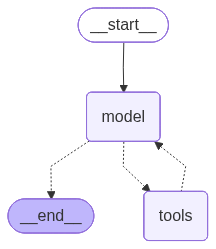

In [18]:
agent

In [17]:
result = agent.invoke({
    "messages": [{"role": "user", "content": user_input}]},{"configurable": {"thread_id": "1"}})

In [24]:
for i in result['messages']:
    i.pretty_print()

================================ Human Message =================================

Find latest news about AI agents
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_U2GOsrEDrR3rpNTXG3LelSQ3)
 Call ID: call_U2GOsrEDrR3rpNTXG3LelSQ3
  Args:
    query: latest news about AI agents
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "New Microsoft AI Agents to Help Modernize Enterprises", "url": "https://aibusiness.com/agentic-ai/new-microsoft-ai-agents-to-help-modernize-enterprises", "content": "Picture of Graham Hope\n\nMarch 16, 2026\n\nPhoto illustration of Copilot on smartphone\n\nMicrosoft has introduced new AI agents designed to help enterprises digitally transform with maximum impact and minimum fuss.\n\nThe releases should help organizations by bringing IT departments and developers into a single workflow, reducing the complexity of

In [21]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from deepagents.middleware.filesystem import FilesystemMiddleware
from langchain_community.tools.tavily_search import TavilySearchResults

# 1️⃣ Initialize the LLM
model = init_chat_model("gpt-4o", temperature=0)

# 2️⃣ Setup FilesystemMiddleware
filesystem_middleware = FilesystemMiddleware(
    backend=lambda rt: CompositeBackend(
                default=StateBackend(rt),
                routes={"/memories/": StoreBackend(rt)}
            ),  # default backend stores files in memory/disk
    system_prompt="""
You have access to a filesystem. 
- Any large tool outputs should be written to a file using write_file.
- When processing large files, you can read them with read_file and summarize them.
- Always provide only a summary or reference in the messages.
""",
    custom_tool_descriptions={
        "ls": "List available files",
        "read_file": "Read the contents of a file",
        "write_file": "Write large outputs to a file",
    }
)

# 3️⃣ Create agent with TavilySearchResults
agent = create_agent(
    model=model,
    tools=[TavilySearchResults(max_results=10)],  # no custom wrapper needed
    middleware=[filesystem_middleware]
)

# 4️⃣ Run agent with user query
user_input = "Find latest AI agent news and summarize the results."

response = agent.invoke(
    {"messages": [{"role": "user", "content": user_input}]}
)

print(response)

{'messages': [HumanMessage(content='Find latest AI agent news and summarize the results.', additional_kwargs={}, response_metadata={}, id='c7f4597a-0289-4491-85b5-3204dc23eb2b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 916, 'total_tokens': 941, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_73c9a1c5a5', 'id': 'chatcmpl-DK37apfNdXyaNNb7uKThVwFyxED5E', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf706-9474-77c2-8282-90eadab92570-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest AI agent news October 2023'}, 'id': 'call_JGemgGxMwORMT6ZAKf3sKLtT', 'type': 'tool_call'}], inva

In [23]:
for i in response['messages']:
    i.pretty_print()

================================ Human Message =================================

Find latest AI agent news and summarize the results.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_JGemgGxMwORMT6ZAKf3sKLtT)
 Call ID: call_JGemgGxMwORMT6ZAKf3sKLtT
  Args:
    query: latest AI agent news October 2023
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "A new Moore's Law for AI agents - AI Digest", "url": "https://theaidigest.org/time-horizons", "content": "Explore the performance of Anthropic, OpenAI, and Google's most capable language models\n\nMar 5, 2024 by Adam Binksmith\n\nHow fast is AI improving?\n\n#### How fast is AI improving?\n\nCompare how GPT-2, GPT-3, GPT-3.5 and GPT-4 perform on the same tasks\n\nOct 26, 2023 by Adam Binksmith, Euan McLean, Eli Lifland, and Aaron Ho\n\nAI Digest\n\n### Stay ahead of the curve\n\nAI Dige

In [ ]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from deepagents.middleware.filesystem import FilesystemMiddleware
from langchain_community.tools.tavily_search import TavilySearchResults

# 1️⃣ Initialize LLM
model = init_chat_model("gpt-4o", temperature=0)

# 2️⃣ Setup FilesystemMiddleware
filesystem_middleware = FilesystemMiddleware(
    backend=None,  # default backend handles disk/memory storage
    system_prompt="""
You have access to a filesystem for storing large tool outputs.
 
Instructions:
1. Every time you run a search tool, write the full output to a unique file using write_file.
2. Keep a dedicated folder (e.g., 'tavily_searches/') for all search outputs.
3. When a user asks a follow-up question, retrieve previous relevant files using read_file and summarize them.
4. Always return a concise summary in 3-5 bullet points, along with the filename(s) of the full results.
""",
    custom_tool_descriptions={
        "ls": "List files and directories",
        "read_file": "Read contents of a file",
        "write_file": "Write data to a file",
    }
)

# 3️⃣ Create agent with TavilySearchResults
agent = create_agent(
    model=model,
    tools=[TavilySearchResults(max_results=10)],
    middleware=[filesystem_middleware]
)

# 4️⃣ Example usage
# First query: fetch and summarize new results
first_query = "Find latest AI agent news and summarize the results."
first_response = agent.invoke(
    {"messages": [{"role": "user", "content": first_query}]}
)
print("First response:\n", first_response)

# Second query: follow-up question using previous searches
followup_query = "What trends in AI agents can we see from previous search results?"
followup_response = agent.invoke(
    {"messages": [{"role": "user", "content": followup_query}]}
)
print("\nFollow-up response:\n", followup_response)

First response:
 {'messages': [HumanMessage(content='Find latest AI agent news and summarize the results.', additional_kwargs={}, response_metadata={}, id='ef4c6af8-0ff8-4f1b-b260-ff4e12900e28'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 969, 'total_tokens': 990, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_51c6266577', 'id': 'chatcmpl-DK3E848466kM6zri12bGIjtAqlUsa', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf70c-bf38-7311-9424-f410b1d7ded1-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest AI agent news'}, 'id': 'call_VeshLyJr6eSenxLEpPzC12uX', 'type': 'tool_call'}], 